# Deep Neural Network (L Layers) from Scratch

## Objective

Build a deep neural network with multiple hidden layers from scratch using NumPy for binary image classification.

## Topics

- Data preprocessing
- Deep neural network architecture
- Parameter initialization
- Forward propagation
- Sigmoid activation
- Binary cross-entropy loss
- Backpropagation
- Gradient descent optimization
- Prediction
- Model evaluation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
from sklearn.metrics import accuracy_score, log_loss
from tqdm import tqdm

In [2]:
sys.path.append(os.path.abspath(".."))
from utilities.utilities import *

In [9]:
def initialize_parameters(dimensions):
    
    parameters = {}
    C = len(dimensions)
    np.random.seed(1)
    for c in range(1, C):
        parameters['W' + str(c)] = np.random.randn(dimensions[c], dimensions[c - 1])
        parameters['b' + str(c)] = np.random.randn(dimensions[c], 1)

    return parameters

In [10]:
def preprocess(X):
    X = X.reshape(X.shape[0], -1)
    X = X/255.0
    return X

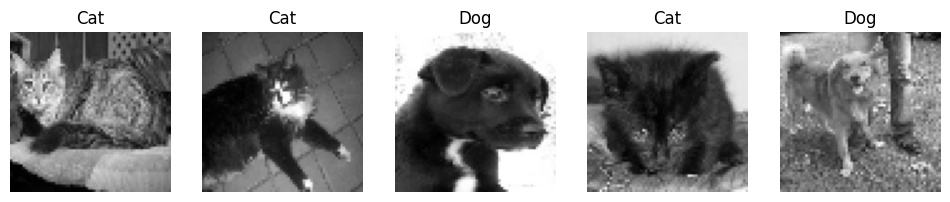

In [11]:
X_train, y_train, X_test, y_test = load_data()
indices = np.random.choice(len(X_train), size=5, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[idx], cmap="gray")  
    plt.title("Dog" if y_train[idx] == 1 else "Cat")  
    plt.axis("off")
plt.show()
X_train = preprocess(X_train).T           
X_test = preprocess(X_test).T     

In [12]:
def forward_propagation(X, parameters):
  
    activations = {'A0': X}
    # The number of parameters wi,bi defines the number of layers when divided by 2
    C = len(parameters) // 2
    for c in range(1, C + 1):
        Z = parameters['W' + str(c)].dot(activations['A' + str(c - 1)]) + parameters['b' + str(c)]
        activations['A' + str(c)] = 1 / (1 + np.exp(-Z))

    return activations

In [13]:
def back_propagation(y, parameters, activations):

  m = y.shape[1]
  C = len(parameters) // 2
  dZ = activations['A' + str(C)] - y
  gradients = {}

  for c in reversed(range(1, C + 1)):
    gradients['dW' + str(c)] = 1/m * np.dot(dZ, activations['A' + str(c - 1)].T)
    gradients['db' + str(c)] = 1/m * np.sum(dZ, axis=1, keepdims=True)
    if c > 1:
      dZ = np.dot(parameters['W' + str(c)].T, dZ) * activations['A' + str(c - 1)] * (1 - activations['A' + str(c - 1)])

  return gradients

In [14]:
def update(gradients, parameters, learning_rate):

    C = len(parameters) // 2

    for c in range(1, C + 1):
        parameters['W' + str(c)] = parameters['W' + str(c)] - learning_rate * gradients['dW' + str(c)]
        parameters['b' + str(c)] = parameters['b' + str(c)] - learning_rate * gradients['db' + str(c)]

    return parameters

In [15]:
def predict(X, parameters):
  activations = forward_propagation(X, parameters)
  C = len(parameters) // 2
  Af = activations['A' + str(C)]
  return Af >= 0.5

In [16]:
def deep_neural_network(X_train, y_train, X_test, y_test, 
                        hidden_layers=(64, 32, 32), 
                        learning_rate=0.005, 
                        n_iter=3000):

    y_train = y_train.reshape(1, -1)
    y_test = y_test.reshape(1, -1)

    dimensions = list(hidden_layers)
    dimensions.insert(0, X_train.shape[0])   # input layer size
    dimensions.append(y_train.shape[0])      # output layer size

    np.random.seed(1)
    parameters = initialize_parameters(dimensions)

    training_history = np.zeros((int(n_iter), 4))  

    C = len(parameters) // 2

    for i in tqdm(range(n_iter)):

        # Forward + backward propagation on training set
        activations = forward_propagation(X_train, parameters)
        gradients = back_propagation(y_train, parameters, activations)
        parameters = update(gradients, parameters, learning_rate)
        Af_train = activations['A' + str(C)]

        # Compute training loss + accuracy
        training_history[i, 0] = log_loss(y_train.flatten(), Af_train.flatten())
        y_pred_train = predict(X_train, parameters)
        training_history[i, 1] = accuracy_score(y_train.flatten(), y_pred_train.flatten())

        # Compute test loss + accuracy
        activations_test = forward_propagation(X_test, parameters)
        Af_test = activations_test['A' + str(C)]
        training_history[i, 2] = log_loss(y_test.flatten(), Af_test.flatten())
        y_pred_test = predict(X_test, parameters)
        training_history[i, 3] = accuracy_score(y_test.flatten(), y_pred_test.flatten())

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(training_history[:, 0], label='train loss')
    plt.plot(training_history[:, 2], label='test loss')
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(training_history[:, 1], label='train accuracy')
    plt.plot(training_history[:, 3], label='test accuracy')
    plt.legend()
    plt.title("Accuracy")

    plt.show()

    print("Train Accuracy:", np.max(training_history[:, 1]))
    print("Test Accuracy :", np.max(training_history[:, 3]))
    print("\n")

    return training_history, parameters


100%|██████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:43<00:00, 28.85it/s]


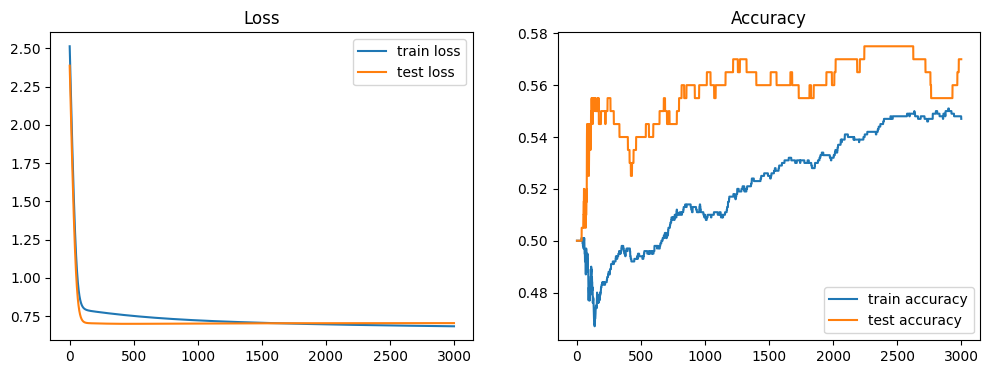

Train Accuracy: 0.551
Test Accuracy : 0.575




In [17]:
training_history, parameters = deep_neural_network(X_train, y_train, X_test, y_test)
y_pred = predict(X_test, parameters)

A deep neural network was successfully implemented from scratch using NumPy, achieving **55.1% training accuracy** and **57.5% test accuracy**.
Increasing the network depth alone did not significantly improve performance, highlighting the importance of architecture design, hyperparameter tuning, and more advanced training techniques.